# Imports

In [1]:
# Automatically reloads modules before each cell execution, so code changes in library are always propogated.
#reload or load? _ext
%load_ext autoreload
%autoreload 2

%load_ext snakeviz

import networkx as nx
from networkx import MultiDiGraph
import osmnx as ox
import numpy as np
import pandas as pd
from difflib import SequenceMatcher
import copy

from graph_manager import GraphManager
import investigation
import plotting
import constants

ox.settings.useful_tags_way = [
    "bridge", "tunnel", "oneway", "lanes", "highway",
     "width", "name", "name:en", "bicycle", "cycleway"]

SEED = 72
SAMPLE_K = 1000

# Network setup

In [2]:
#NOTE the length attribute is given in meters
#You project not to fix lengths, but to make sure your geometry math (like areas or spatial intersections) makes sense in linear units.
#Simplify is used to significantly reduce the number of nodes, removing dead ends and combining nodes with no intersections
LOCATION = "Malta (island)"

my_graph = GraphManager(LOCATION)

Loading OSM networks for Malta (island)...
creating master graph network...
Adding elevation data.....
Imputing missing elevation values
Iteration 1: imputed 392 nodes
Iteration 2: imputed 90 nodes
Iteration 3: imputed 20 nodes
Iteration 4: imputed 6 nodes
Iteration 5: imputed 0 nodes
node elevation nan <class 'float'>
NOde246587560 elevation is problematic :/
NOde5243805554 elevation is problematic :/
NOde9068823240 elevation is problematic :/
node elevation 59.0 <class 'float'>
Number of localities: 54


## Road type classification

In [3]:
my_graph.summarise_road_type_stats(my_graph.G_master)

Highway type counts:
residential: 39042
service: 15822
track: 10989
tertiary: 6150
secondary: 5330
non_motorised: 2842
trunk: 2122
primary: 1985
cycleway: 305
-------
bikeway classification type counts:
None: 82021
yes: 2183
designated: 317
no: 45
permissive: 14
permit: 4
private: 3
------
cycleway type counts:
None: 84299
no: 201
shared: 30
track: 21
shared_lane: 14
lane: 14
crossing: 8


In [4]:
print("Nodes:", my_graph.G_master.number_of_nodes())
print("Edges (total, counts parallel edges separately):", my_graph.G_master.number_of_edges())
print(my_graph.G_master.graph)

Nodes: 35755
Edges (total, counts parallel edges separately): 84587
{'created_date': '2025-11-14 22:01:59', 'created_with': 'OSMnx 2.0.5', 'crs': <Projected CRS: EPSG:32633>
Name: WGS 84 / UTM zone 33N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°E and 18°E, northern hemisphere between equator and 84°N, onshore and offshore. Austria. Bosnia and Herzegovina. Cameroon. Central African Republic. Chad. Congo. Croatia. Czechia. Democratic Republic of the Congo (Zaire). Gabon. Germany. Hungary. Italy. Libya. Malta. Niger. Nigeria. Norway. Poland. San Marino. Slovakia. Slovenia. Svalbard. Sweden. Vatican City State.
- bounds: (12.0, 0.0, 18.0, 84.0)
Coordinate Operation:
- name: UTM zone 33N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
, 'simplified': True}


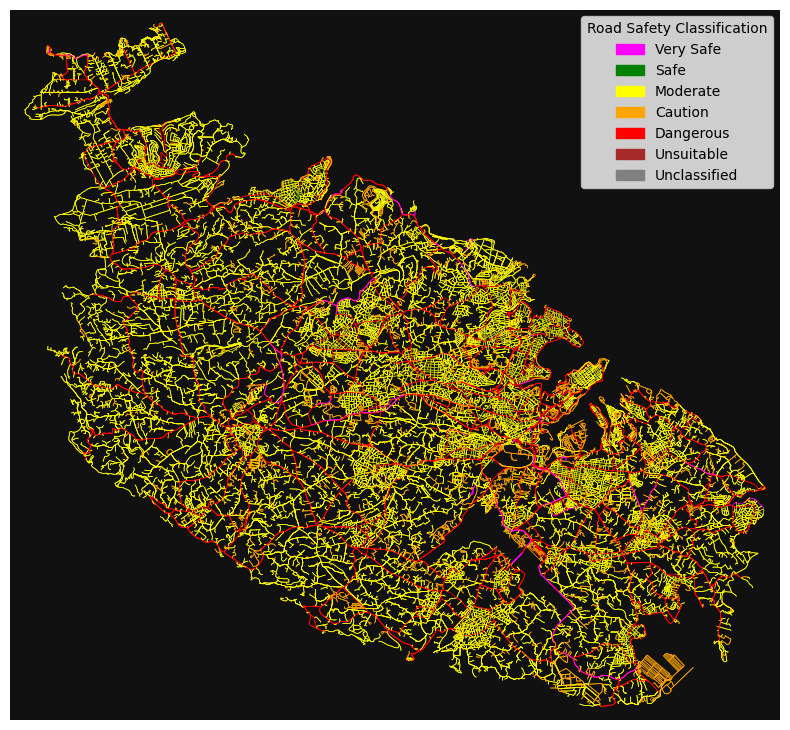

In [5]:
plotting.plot_road_classification(my_graph.G_master)

In [6]:
"""investigation.analyze_parallel_edges(my_graph.G_master)
investigation.compare_parallel_edges(my_graph.G_master)
investigation.plot_parallel_edges(my_graph.G_master)
print("-----")"""

'investigation.analyze_parallel_edges(my_graph.G_master)\ninvestigation.compare_parallel_edges(my_graph.G_master)\ninvestigation.plot_parallel_edges(my_graph.G_master)\nprint("-----")'

## Topology

Fetched elevations for 35755 / 35755 nodes


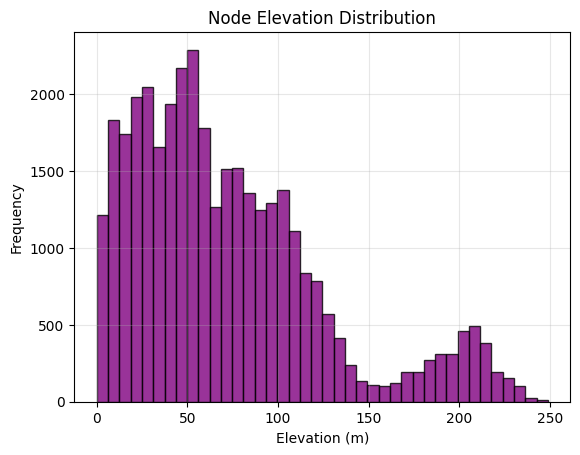

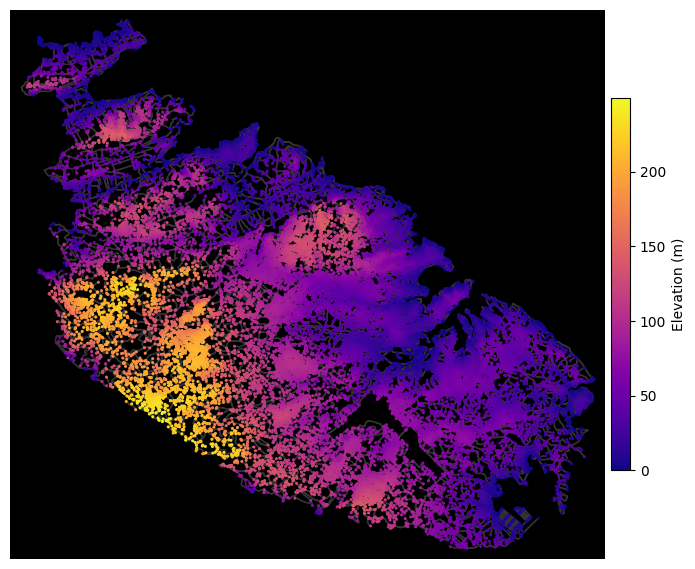

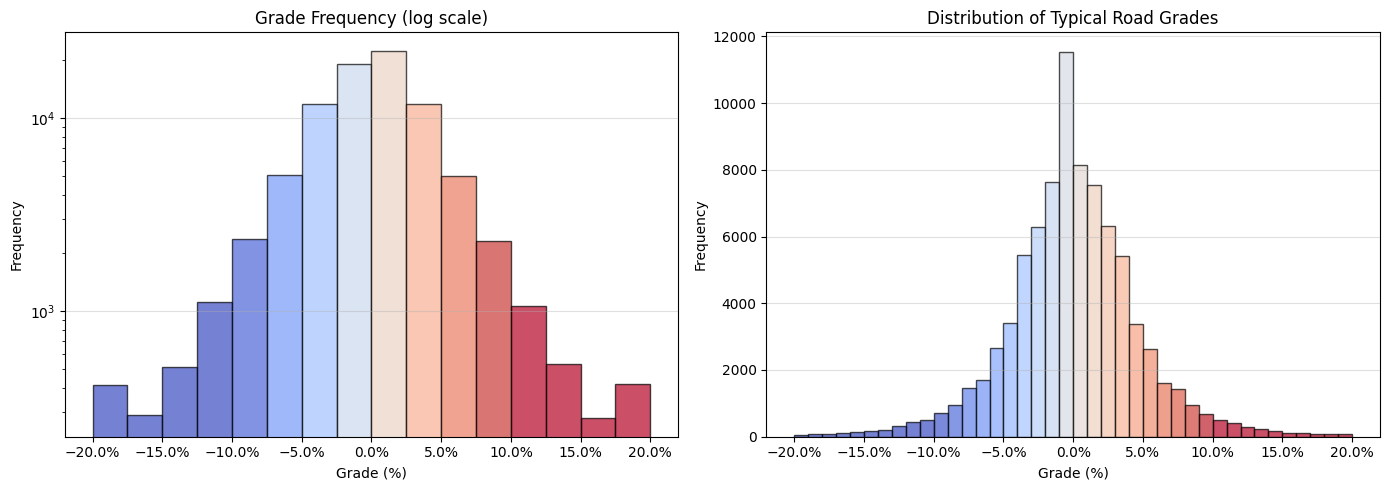

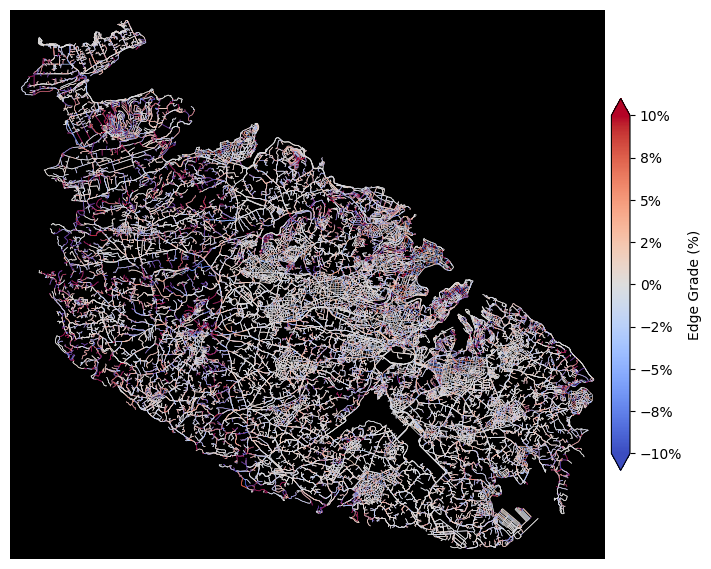

In [7]:
plotting.plot_elevation(my_graph.G_master)
plotting.plot_grades(my_graph.G_master)

## Network statistics

In [8]:
"""# what sized area does our network cover in square meters?
bike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes
graph_area_m = bike_nodes_proj.union_all().convex_hull.area
# show some basic stats about the network
stats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)"""

'# what sized area does our network cover in square meters?\nbike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes\ngraph_area_m = bike_nodes_proj.union_all().convex_hull.area\n# show some basic stats about the network\nstats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)'

In [9]:
edge_keys = set()
for u,v,data in my_graph.G_master.edges(data=True):
    edge_keys.update(data.keys())
print(edge_keys)

{'car_allowed', 'cycleway', 'geometry', 'bridge', 'name', 'bike_lanes', 'tunnel', 'bike_allowed', 'highway', 'grade', 'risk_factor', 'osmid', 'length', 'name:en', 'bicycle', 'car_lanes', 'reversed', 'safety', 'width', 'oneway', 'grade_abs', 'region'}


# Generating city level subgraphs

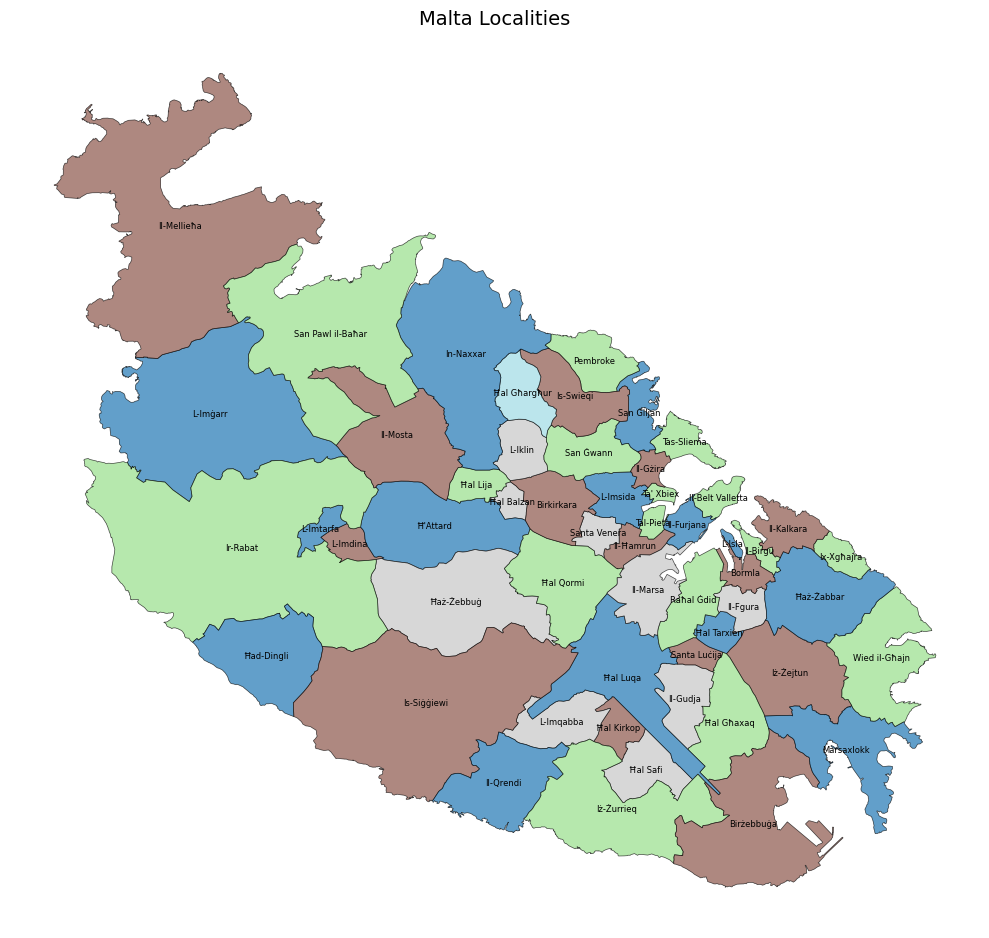

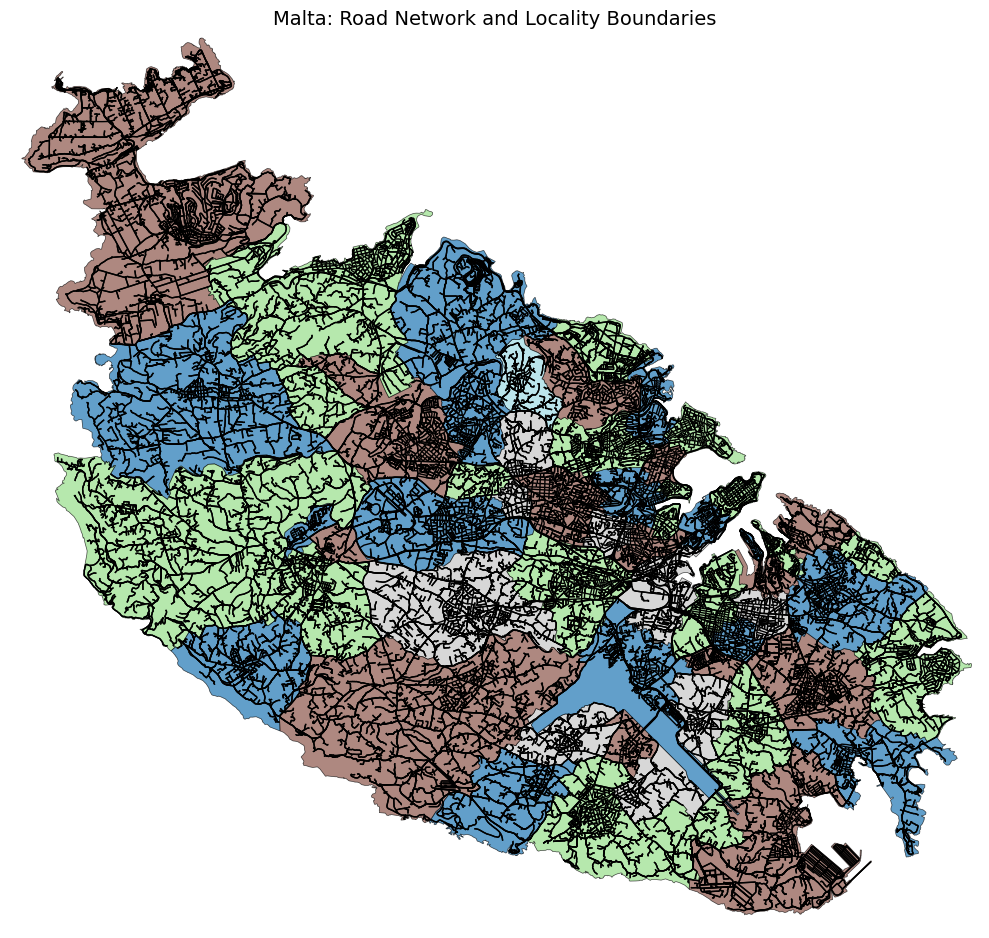

In [10]:
gdf_localities_proj = my_graph.gdf_localities.to_crs(my_graph.G_master.graph["crs"])

# Assign distinct colors
gdf_colored = plotting.assign_adjacent_colors(gdf_localities_proj, cmap_name="tab20")

# Plot only polygons
plotting.plot_colored_polygons(gdf_colored, title="Malta Localities")

# Plot polygons + road network overlay
plotting.plot_colored_polygons(
    gdf_colored,
    G=my_graph.G_master,
    title="Malta: Road Network and Locality Boundaries",
    annotate=False
)

In [11]:
# count edges missing 'geometry' (or with geometry == None)
G = my_graph.G_master
missing = [(u, v, k) for u, v, k, d in G.edges(keys=True, data=True) if d.get("geometry") is None]
print("Edges without geometry:", len(missing), "/", G.number_of_edges(), f"({100*len(missing)/G.number_of_edges():.2f}%)")
# show up to 10 examples
print("Examples:", missing[:10])

Edges without geometry: 35757 / 84587 (42.27%)
Examples: [(5044930083, 6255998915, 0), (291204398, 155218892, 0), (151117016, 151114918, 0), (151117016, 1456708243, 0), (1383638903, 158677856, 0), (278317188, 197905, 0), (197909, 262830238, 0), (197909, 295093497, 0), (262830238, 4625335369, 0), (295093497, 197909, 0)]


In [12]:
subgraphs = {}
total_nodes = 0
total_edges = 0
for idx, row in gdf_localities_proj.iterrows():
    name = row["name"]

    G_sub = my_graph.make_region_subgraph(my_graph.G_master, name)
    subgraphs[name] = G_sub
    total_nodes += len(G_sub.nodes)
    total_edges += len(G_sub.edges)
    print(f"✅ Created subgraph for {name}: {len(G_sub.nodes)} nodes, {len(G_sub.edges)} edges")

print(f"total_nodes{total_nodes}, total_edges{total_edges}")

✅ Created subgraph for Il-Birgu: 0 nodes, 0 edges
✅ Created subgraph for Tas-Sliema: 0 nodes, 0 edges
✅ Created subgraph for L-Imġarr: 0 nodes, 0 edges
✅ Created subgraph for Il-Mellieħa: 35755 nodes, 84587 edges
✅ Created subgraph for Il-Ħamrun: 0 nodes, 0 edges
✅ Created subgraph for Santa Venera: 0 nodes, 0 edges
✅ Created subgraph for L-Imdina: 0 nodes, 0 edges
✅ Created subgraph for Ħal Balzan: 0 nodes, 0 edges
✅ Created subgraph for Ħ'Attard: 0 nodes, 0 edges
✅ Created subgraph for Ħaż-Żebbuġ: 0 nodes, 0 edges
✅ Created subgraph for Ħal Safi: 0 nodes, 0 edges
✅ Created subgraph for Ħal Kirkop: 0 nodes, 0 edges
✅ Created subgraph for L-Imqabba: 0 nodes, 0 edges
✅ Created subgraph for Ħal Qormi: 0 nodes, 0 edges
✅ Created subgraph for Il-Gudja: 0 nodes, 0 edges
✅ Created subgraph for Santa Luċija: 0 nodes, 0 edges
✅ Created subgraph for Ħal Tarxien: 0 nodes, 0 edges
✅ Created subgraph for Il-Fgura: 0 nodes, 0 edges
✅ Created subgraph for Iż-Żejtun: 0 nodes, 0 edges
✅ Created subgra

# Topological Metrics

Evaluating how good a network is

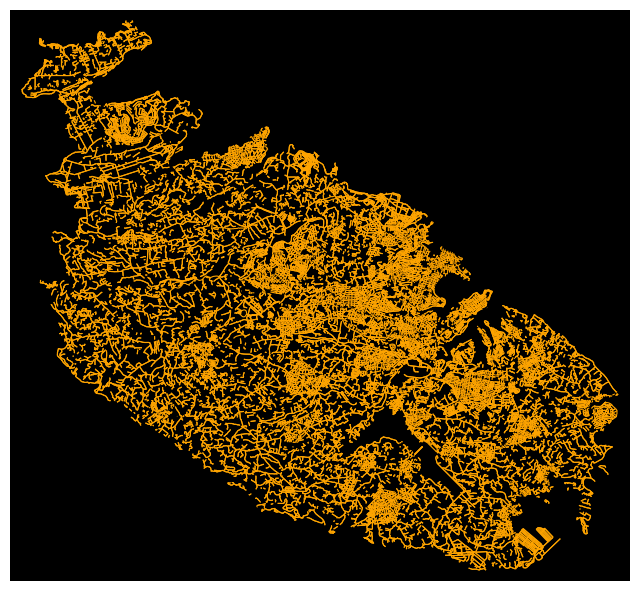

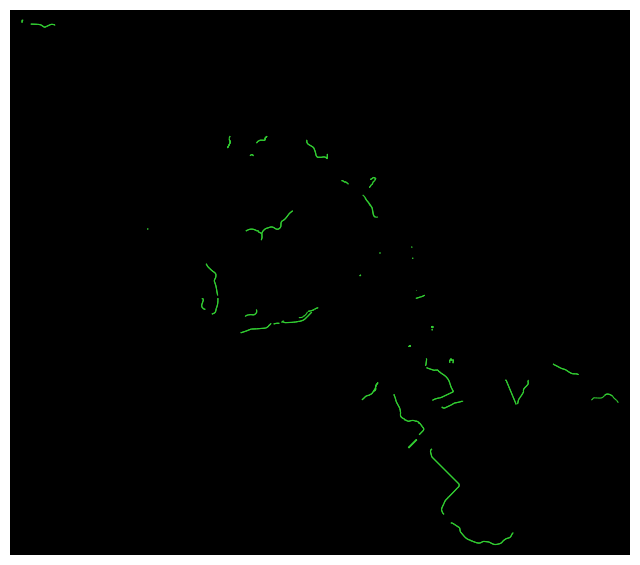

In [ ]:
fig, ax = ox.plot_graph(
    my_graph.make_bikeable_subgraph(my_graph.G_master),
    node_size=0,
    edge_color="orange",
    edge_linewidth=0.8,
    bgcolor="k"
)

fig, ax = ox.plot_graph(
    my_graph.make_protected_subgraph(my_graph.G_master),
    node_size=0,
    edge_color="limegreen",
    edge_linewidth=0.8,
    bgcolor="k"
)

In [ ]:
# Connectedness - describing whether the network forms a single, navigable system or remains fragmented into multiple component
def calc_connectedness(G:MultiDiGraph, G_lcc:MultiDiGraph) -> dict:
    num_components = nx.number_strongly_connected_components(G)
    lcc_length = float(sum(d.get("length", 0) for _, _, d in G_lcc.edges(data=True)))

    return {
        "num_components": num_components,
        "lcc_length": lcc_length,
    }


"""def calc_directness(Gb_lcc:MultiDiGraph, G_drive:MultiDiGraph, k = SAMPLE_K, seed=SEED):
    #TODO update when I actually have OD matrix data
    rng = random.Random(seed)

    nodes_b = list(Gb_lcc.nodes())
    if len(nodes_b) < 2:
        raise ValueError("Bike LCC has fewer than 2 nodes.")
    K_eff = min(k, len(nodes_b) * 5)  # keep reasonable number of pairs
    rng.seed(seed)
    ods = []
    while len(ods) < K_eff:
        o = rng.choice(nodes_b)
        d = rng.choice(nodes_b)
        if o != d:
            ods.append((o, d))
            
    pass"""

def calc_centrality(G_lcc:MultiDiGraph, k=SAMPLE_K, seed = SEED) -> dict:
    """Calculate comprehensive centrality metrics for cycling network assessment"""
    #NOTE full centrality is O(n^3), k is instead used to approximate

    num_nodes = len(G_lcc.nodes)
    k_eff = min(k, num_nodes)
    
    # Edge betweenness centrality - connectors for network resilience
    edge_between_cent = nx.edge_betweenness_centrality(G_lcc, weight="length", normalized=True, k=k_eff, seed = seed)
    mean_edge_between_cent = float(np.mean(list(edge_between_cent.values())))

    # betweenness centrality - measures how frequently a link lies on the shortest paths between all node pair
    node_between_cent = nx.betweenness_centrality(G_lcc, weight="length", normalized=True, k=k_eff, seed = seed)
    mean_node_between_cent = float(np.mean(list(node_between_cent.values())))

    #closeness_centrality - how close all other nodes are 
    node_close_cent = nx.closeness_centrality(G_lcc, distance="length")
    mean_node_close_cent = float(np.mean(list(node_close_cent.values())))

    degrees = [d for _, d in G_lcc.degree()]
    mean_degree = float(np.mean(degrees))
        
    return {
        "mean_edge_betweenness": mean_edge_between_cent,
        "mean_node_betweenness": mean_node_between_cent,
        "mean_node_closeness": mean_node_close_cent,
        "mean_degree": mean_degree,
    }


def network_evaluation(G:MultiDiGraph) -> dict:
    G_lcc = ox.truncate.largest_component(G, strongly=True) #NOTE strongly connected true since roads cycle infrastructure is directional

    connectedness = calc_connectedness(G, G_lcc)
    centrality  = calc_centrality(G_lcc)
    results = {**connectedness, **centrality}
    return results

In [ ]:
# Directness - measures how efficiently users can travel between two point

# Centrality
network_evaluation(my_graph.make_protected_subgraph(my_graph.G_master))
## Degree - number of connections per node

{'num_components': 70,
 'lcc_length': 102359918.91440608,
 'mean_edge_betweenness': 0.18888888888888886,
 'mean_node_betweenness': 0.33333333333333337,
 'mean_node_closeness': 6.188969074572137e-08,
 'mean_degree': 3.75}

# Optimisation Approaches 

## Heuristic Approaches

Centrality - betweeness and closeness

In [ ]:
def heuristic(G_master:MultiDiGraph, k=SAMPLE_K, seed=SEED):
    G_drive = my_graph.make_drive_subgraph(G_master)
    edges_between_cent = nx.edge_betweenness_centrality(G_drive, weight="length", normalized=True, k=k, seed=seed)
    max_between_cent_edge = max(edges_between_cent, key=edges_between_cent.get)
    print(max_between_cent_edge)
    
    u,v,k = max_between_cent_edge
    print(f"edge before: {G_master[u][v][k]}")
    my_graph.reallocate_edge(G_master, max_between_cent_edge)
    print(f"edge after: {G_master[u][v][k]}" )

(9250737080, 378205575, 0)
edge before: {'osmid': [411495826, 438410196], 'highway': 'trunk', 'oneway': True, 'reversed': False, 'length': np.float64(1070647.4122379208), 'geometry': <LINESTRING (454408.805 3970175.252, 454423.489 3970281.257, 454425.012 3970...>, 'car_allowed': True, 'bike_allowed': False, 'grade': 0.020915932792541746, 'grade_abs': 0.020915932792541746, 'car_lanes': 5, 'bike_lanes': 0, 'safety': <SafetyClass.DANGEROUS: 'dangerous'>, 'risk_factor': 4.0, 'region': 'Il-Marsa', 'name': 'Triq Aldo Moro', 'name:en': 'Aldo Moro Road'}
edge after: {'osmid': [411495826, 438410196], 'highway': 'trunk', 'oneway': True, 'reversed': False, 'length': np.float64(1070647.4122379208), 'geometry': <LINESTRING (454408.805 3970175.252, 454423.489 3970281.257, 454425.012 3970...>, 'car_allowed': True, 'bike_allowed': True, 'grade': 0.020915932792541746, 'grade_abs': 0.020915932792541746, 'car_lanes': 4, 'bike_lanes': 1, 'safety': <SafetyClass.SAFE: 'safe'>, 'risk_factor': 4.0, 'region': 

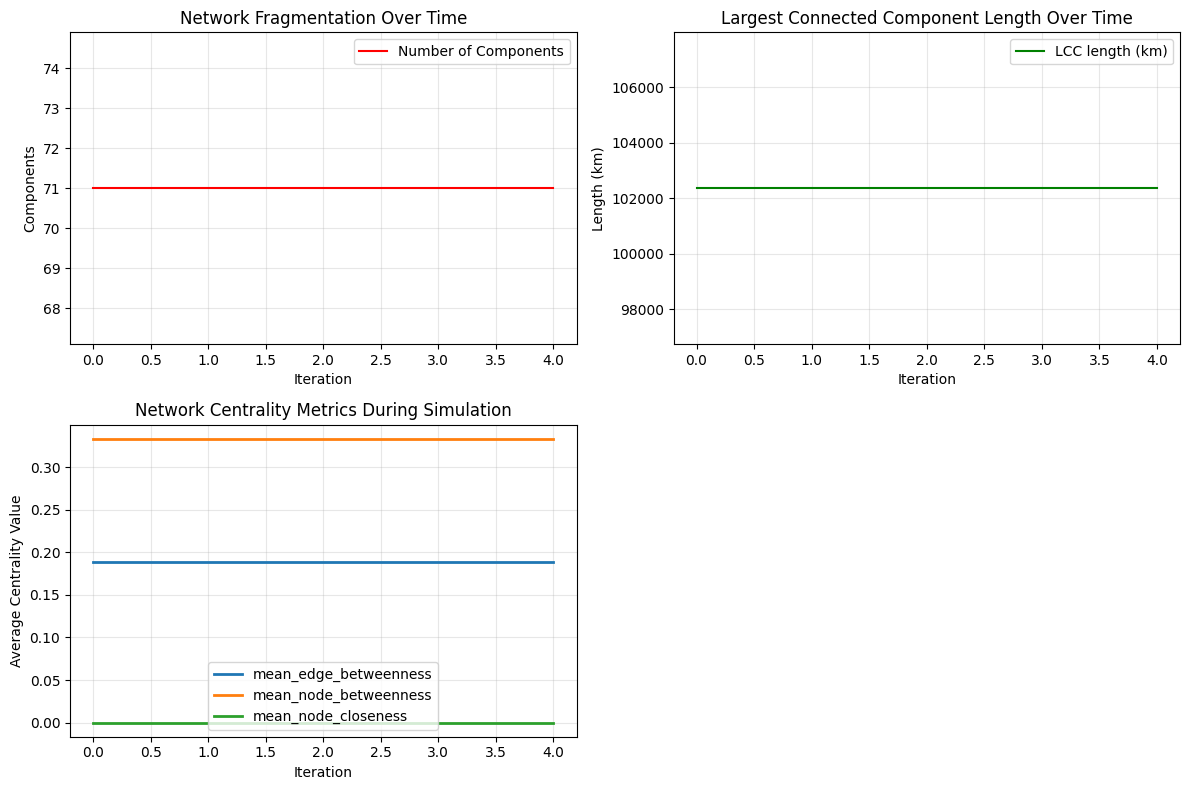

In [ ]:
def run_simulation(graphs:GraphManager):
    G_working = copy.deepcopy(graphs.G_master)

    evaluations = []
    for i in range(5):
        #print(f"{i}th iteration running...")
        #NOTE heuristic is taking too much time
        heuristic(G_working, k=10)
        #print("heuristic complete")

        protected_subgraph = graphs.make_protected_subgraph(G_working)
        #print("making protected subgraph")
        evaluation = network_evaluation(protected_subgraph)
        #print("evaluating protected subgraph")
        evaluations.append(evaluation)
    
    return evaluations

%snakeviz -t results = run_simulation(my_graph)

df_results = pd.DataFrame(results)
df_results.index.name = "iteration"

plotting.plot_evaluation(df_results)
